# Анализ системы метрик приложения Procrastinate Pro+


Ознакомимся с приложением Procrastinate Pro+, которое предоставляет пользователям доступ к развлекательному контенту: видео, подкастам и блогам. Пользователи могут выбрать несколько пакетов контента. Пакеты различаются по цене, объёму и содержанию.

К началу лета в приложении появился новый вид контента — спортивный. С его помощью менеджеры стремятся расширить аудиторию, добавив в неё пользователей, которые увлекаются спортом и здоровым образом жизни.

К запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. Согласно бизнес-модели продукта, привлечение должно окупиться за первые 28 дней (4 недели).

После запуска нового контента и изменения стратегии интерес к продукту в целом вырос, но выручка начала стагнировать. Нужно разобраться, почему это происходит.

### Задачи:
- провести анализ юнит-экономики продукта в динамике за первые 28 дней;
- разобраться в причинах стагнации выручки;
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости;
- дать рекомендации отделу маркетинга.

---

### Данные

В нашем распоряжении есть данные о посещениях приложения, покупках и расходах на маркетинг.
Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.

---

<a class="anchor" id="10-bullet"></a>
## Содержимое проекта

* [1 Загрузка и предобработка данных](#1-bullet)
* [2 Подготовка данных к когортному анализу](#2-bullet)
* [3 Анализ месячной динамики основных метрик продукта](#3-bullet)
    * [3.1 Анализ метрик вовлечённости в продукт](#31-bullet)
    * [3.2 Анализ финансовых метрик CAC, LTV и ROI за первые 28 дней с момента привлечения](#32-bullet)
* [4 Анализ метрик в разрезе источника привлечения](#4-bullet)
    * [4.1 Самые популярные источники привлечения](#41-bullet)
    * [4.2 Динамика изменения метрик на 28-й день в разрезе источника](#42-bullet)
* [5 Анализ периода окупаемости маркетинговых вложений](#5-bullet)
* [6 Выводы и рекомендации](#6-bullet)   
        
---

<a class="anchor" id="1-bullet"></a>
## 1 Загрузка и предобработка данных

Загрузим данные и получим основную информацию о них. Проведем необходимую предобработку. 

In [1]:
# Импортируем библиотеки для работы с данными и визуализациями
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
# Выгружаем данные о посещениях приложения пользователями
visits = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_visits.csv', 
                     parse_dates=['session_start','session_end'])

display(visits.head())
print()
visits.info()

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   region         161865 non-null  object        
 2   device         161865 non-null  object        
 3   channel        161865 non-null  object        
 4   session_start  161865 non-null  datetime64[ns]
 5   session_end    161865 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 7.4+ MB


- Датасет `visits` содержит 6 столбцов и 161 865 строк с информацией о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года. Пропусков в таблице нет. 

Временные данные `session_start`, `session_end` с датой и временем начала и окончания сессии преобразуем к формату даты для дальнейшего анализа данных.


In [3]:
# Приведем тип времненных данных 
visits[['session_start', 'session_end']] = (
    visits[['session_start', 'session_end']]
    .apply(lambda x: x.dt.floor('D')))

display(visits.head())

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01,2024-04-01
1,892885906464,India,tv,RocketSuperAds,2024-04-01,2024-04-01
2,517003690029,India,mobile,MediaTornado,2024-04-01,2024-04-01
3,185156659289,India,mobile,MediaTornado,2024-04-01,2024-04-01
4,409503040345,India,mobile,RocketSuperAds,2024-04-01,2024-04-01


In [4]:
# Выгружаем информацию о покупках
orders = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_orders.csv', parse_dates=['event_dt'])

display(orders.head())
print()
orders.info()

,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   33893 non-null  int64         
 1   event_dt  33893 non-null  datetime64[ns]
 2   revenue   33893 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 794.5 KB


- Датасет `orders` содержит 3 столбца и 33 893 строки с информацией о покупках. Пропусков в таблице нет. 

Временные данные `event_dt` с датой и временем покупки приведем к формату даты.

In [5]:
# Приведем тип времненных данных к дате
orders['event_dt'] = orders['event_dt'].dt.floor('D')

display(orders.head())

,user_id,event_dt,revenue
0,771951256319,2024-04-01,2.99
1,829942381059,2024-04-01,2.99
2,727879856738,2024-04-01,14.99
3,481270888930,2024-04-01,2.99
4,844695029762,2024-04-01,2.99


In [6]:
# Выгружаем о затратах на маркетинг
costs = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_costs.csv', parse_dates=['dt'])

display(costs.head())
print()
costs.info()

,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       976 non-null    datetime64[ns]
 1   channel  976 non-null    object        
 2   costs    976 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 23.0+ KB


- Датасет `costs` содержит 3 столбца и 976 строк с информацией о затратах на маркетинг. Пропусков в таблице нет. 

- Данные о посещениях приложения, покупках и расходах на маркетинг загружены. Временные данные преобразованы к формату дня для дальнейшего анализа.

* [Назад к содержанию](#10-bullet)
---
<a class="anchor" id="2-bullet"></a>
## 2 Подготовка данных к когортному анализу

Подготовим данные к когортному анализу с учётом того, что мы будем изучать окупаемость привлечения пользователей за первые 28 дней.

Для каждого пользователя найдем:
- дату первой сессии (дата привлечения пользователя, `first_dt`);
- канал привлечения (`first_channel`);
- стоимость привлечения пользователя (`cac`).

Результаты сохраним в новой таблице `profiles`.

Далее добавим к данным с событиями и покупками информацию о первом источнике привлечения и дату привлечения пользователя из созданной таблицы. После этого рассчитаем дневной лайфтайм для каждого события или покупки и добавим в таблицу в виде целого числа. В дальнейшем при проведении когортного анализа будем использовать информацию о первом источнике привлечения пользователя.

In [7]:
# Сортируем данные по дате совершения событий
visits_ordered = visits.sort_values(by='session_start')

# Находим дату первой сессии и канал привлечения
profiles = visits_ordered.groupby('user_id').agg(
    first_dt=('session_start', 'min'),
    first_channel=('channel', 'first')).reset_index()

profiles['first_dt'] = profiles['first_dt'].dt.floor('D')

display(profiles.head())

,user_id,first_dt,first_channel
0,26034876,2024-05-29,FaceBoom
1,69890364,2024-06-28,RocketSuperAds
2,75610104,2024-06-09,FaceBoom
3,76692397,2024-10-21,FaceBoom
4,80224421,2024-06-21,FaceBoom


- Чтобы рассчитать стоимость привлечения пользователя посчитаем, сколько новых пользователей пришло в этот день и канал.

In [8]:
# Новые пользователи по дням и каналам
new_users = profiles.groupby(['first_dt', 'first_channel'])['user_id'].nunique().reset_index()
new_users = new_users.rename(columns={'user_id':'new_users'})

# Объединим с данными о маркетинговых затратах
cac = pd.merge(costs, new_users, how='left', 
               left_on=['dt', 'channel'], right_on=['first_dt', 'first_channel'])

# Рассчитаем стоимость привлечения пользователя
cac['cac'] = cac['costs'] / cac['new_users']

# Добавим САС в таблицу profiles
profiles = profiles.merge(cac[['dt', 'channel', 'cac']], how='left', 
                          left_on=['first_dt', 'first_channel'], right_on=['dt', 'channel']).drop(columns=['dt', 'channel'])

display(profiles.head())

,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21,FaceBoom,1.208981


- Далее добавляем к таблицам `visits` и `orders` информацию о первом источнике привлечения и дату привлечения пользователя, рассчитаем дневной лайфтайм для каждого события.

In [9]:
# Добавляем к visits дату первого визита и канал привлечения
visits = visits.merge(profiles, how='left', on='user_id')

# Считаем дневной лайфтайм для visits
visits['lifetime'] = (visits['session_start'] - visits['first_dt']).dt.days

display(visits.head())

,user_id,region,device,channel,session_start,session_end,first_dt,first_channel,cac,lifetime
0,631105188566,India,desktop,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0.249160,0
1,892885906464,India,tv,RocketSuperAds,2024-04-01,2024-04-01,2024-04-01,RocketSuperAds,0.886429,0
2,517003690029,India,mobile,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0.249160,0
3,185156659289,India,mobile,MediaTornado,2024-04-01,2024-04-01,2024-04-01,MediaTornado,0.249160,0
4,409503040345,India,mobile,RocketSuperAds,2024-04-01,2024-04-01,2024-04-01,RocketSuperAds,0.886429,0


In [10]:
# Добавляем к orders дату первого визита и канал привлечения
orders = orders.merge(profiles, how='left', on='user_id')

# Считаем дневной лайфтайм для visits
orders['lifetime'] = (orders['event_dt'] - orders['first_dt']).dt.days

display(orders.head())

,user_id,event_dt,revenue,first_dt,first_channel,cac,lifetime
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0.939390,0
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0.742467,0
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0


Данные подготовлены к когортному анализу. Все необходимые метрики для изучения окупаемости маркетинговых вложений за первые 28 дней есть: канал привлечения, стоимость привлечения пользователя (CAC), даты событий и лайфтайм.

Таблицы готовы к агрегированию по когортам для анализа вовлечённости и финансовых показателей (LTV, ROI) в разрезе источников привлечения.

* [Назад к содержанию](#10-bullet)
---
<a class="anchor" id="3-bullet"></a>
## 3 Анализ месячной динамики основных метрик продукта

<a class="anchor" id="31-bullet"></a>
### 3.1 Анализ метрик вовлечённости в продукт

Начнем анализ данных с изучения динамики активности пользователей и их вовлечённости в продукт. 

Рассчитаем по всем данным значения DAU, MAU и Stickiness и визуализируем их. 
Активными будем считать всех пользователей, которые взаимодействовали с приложением.


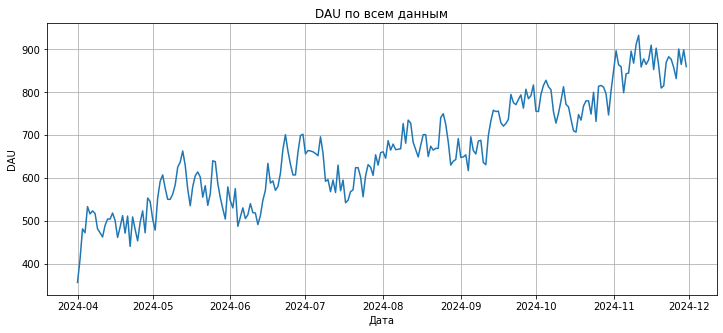

In [11]:
# Расчёт DAU
dau = (visits.groupby('session_start')['user_id'].nunique().reset_index()
      .rename(columns={'session_start': 'date', 'user_id':'dau'}))

# Cтроим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(dau['date'], dau['dau'])
plt.title('DAU по всем данным')
plt.xlabel('Дата')
plt.ylabel('DAU')

plt.grid()
plt.show()

- Показатель DAU демонстрирует сильный восходящий тренд: ежедневная активная аудитория выросла более чем вдвое (с ~350 в апреле до ~850-900 пользователей к ноябрю).  Резкий рост активной базы подтверждает, что новые маркетинговые усилия и запуск спортивного контента успешно привлекли и активировали больше пользователей, что соответствует вводным данным о росте интереса к продукту. 

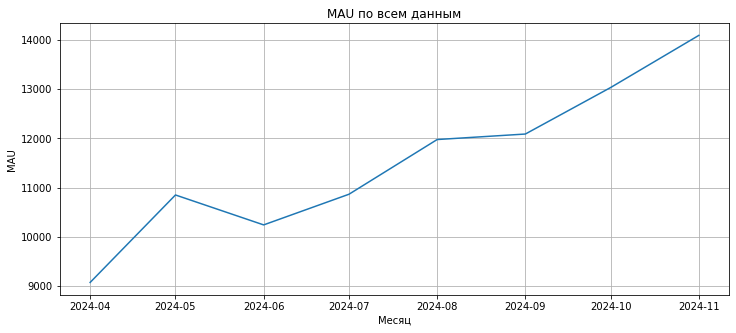

In [12]:
# Расчёт MAU
visits['month'] = visits['session_start'].dt.to_period('M').dt.to_timestamp()

mau = (visits.groupby('month')['user_id'].nunique().reset_index()
      .rename(columns={'user_id':'mau'}))

# Cтроим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(mau['month'], mau['mau'])
plt.title('MAU по всем данным')
plt.xlabel('Месяц')
plt.ylabel('MAU')

plt.grid()
plt.show()

- Показатели MAU, также как и DAU, выросли к концу 2024 года относительно апреля 2024 года (с ~9 тысяч активных пользователей к ~14 тысяч). Однако с мая по июнь наблюдается падение матрики MAU, что совпадает с анонсированным периодом корректировки маркетинговой стратегии и запуска нового контента. Этот краткосрочный спад может указывать на начальные проблемы с эффективностью новой кампании. В последующие месяцы рост возобновляется.

Произведем расчёт метрики Stickiness.

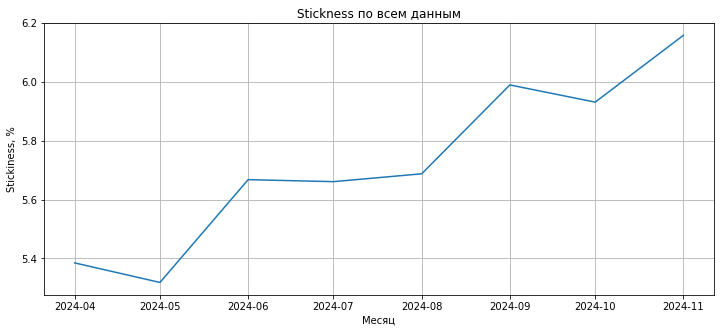

In [13]:
# Рассчитаем среднемесячные dau
dau['month'] = dau['date'].dt.to_period('M').dt.to_timestamp()
dau_monthly = (dau.groupby('month')['dau'].mean().reset_index()
               .rename(columns={'dau':'avg_dau'}))

# Расчёт Stickness
stick = pd.merge(mau, dau_monthly, how='left', on='month')
stick['stick'] = 100 * (stick['avg_dau'] / stick['mau'])

# Cтроим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(stick['month'], stick['stick'])
plt.title('Stickness по всем данным')
plt.xlabel('Месяц')
plt.ylabel('Stickiness, %')

plt.grid()
plt.show()

- Показатель Stickiness вырос незначительно (с ~5.3 до ~6.2).  Рост общей аудитории (DAU, MAU) не сопровождается существенным ростом лояльности/вовлеченности. Если бы новые пользователи активно вовлекались в продукт, метрика Stickiness должна была бы продемонстрировать более выраженный рост.  Это говорит о том, что новые пользователи не стали существенно более вовлеченными, чем старые. Это может быть одной из причин стагнации выручки, поскольку рост аудитории не переходит в пропорциональный рост ценности пользователя.

* [Назад к содержанию](#10-bullet)
---
<a class="anchor" id="32-bullet"></a>
### 3.2 Анализ финансовых метрик CAC, LTV и ROI за первые 28 дней с момента привлечения
В разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC).
- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.

Здесь и далее при расчёте LTV и ROI будем учитывать всех привлечённых пользователей когорты.

Визуализируем метрики и сформулируем небольшой промежуточный вывод. Сделаем акцент на общей динамике изменения метрик с учётом появления нового контента в начале лета.

Поскольку нам нужно считать метрики на 28й день, а данные заканчиваются ноябрем, то сначала исключим пользователей, привлеченных в ноябре, так как это неполный месяц. 

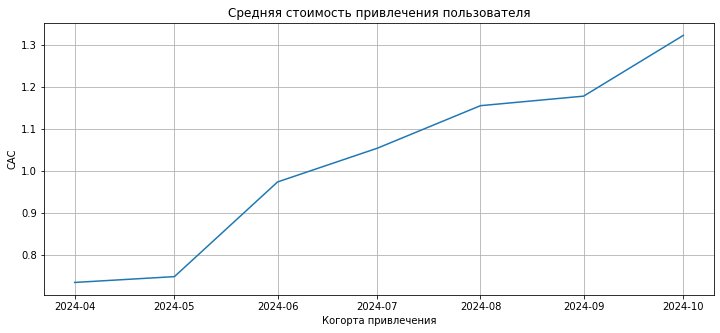

In [14]:
# Создаем столбец cohort на основе даты привлечения (first_dt)
visits['cohort'] = visits['first_dt'].dt.to_period('M').dt.to_timestamp()
orders['cohort'] = orders['first_dt'].dt.to_period('M').dt.to_timestamp()
profiles['cohort'] = profiles['first_dt'].dt.to_period('M').dt.to_timestamp()

# Исключим пользователей, привлеченных в ноябре 
profiles_28 = profiles[profiles['first_dt'] < '2024-11-01']

visits_28 = visits[
    (visits['user_id'].isin(profiles_28['user_id'])) &
    (visits['lifetime'] <= 27)]

orders_28 = orders[
    (orders['user_id'].isin(profiles_28['user_id'])) &
    (orders['lifetime'] <= 27)]

# Рассчитаем среднюю стоимость привлечения пользователя
cac_df = (profiles_28.groupby('cohort')['cac'].mean().reset_index()
               .rename(columns={'cac':'avg_cac'}))

# Cтроим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(cac_df['cohort'], cac_df['avg_cac'])
plt.title('Средняя стоимость привлечения пользователя')
plt.xlabel('Когорта привлечения')
plt.ylabel('CAC')

plt.grid()
plt.show()

- Средняя стоимость привлечения пользователя демонстрирует четкий восходящий тренд на протяжении всего периода. Начиная с мая-июня (период запуска нового контента и корректировки маркетинга) CAC начал стабильно расти, что говорит о том, что привлечение каждого нового пользователя становится дороже. Этот рост является первым потенциальным фактором стагнации финансовой эффективности продукта.

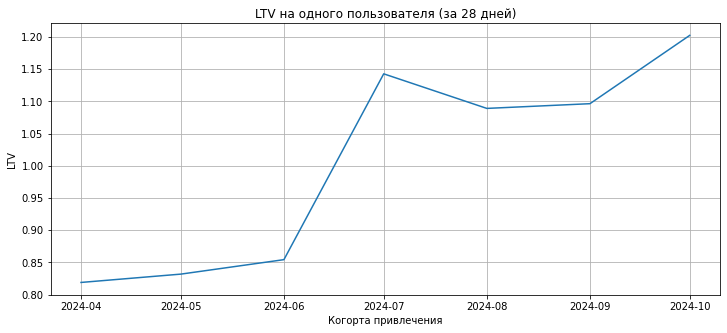

In [15]:
# Посчитаем количество новых пользователей в каждой когорте
new_users_cohort = (
    profiles_28.groupby(profiles_28['first_dt'].dt.to_period('M').dt.to_timestamp())['user_id']
    .nunique().reset_index()
    .rename(columns={'first_dt':'cohort', 'user_id':'new_users_count'}))

# Группируем по когорте привлечения
ltv_cohort = (orders_28.groupby('cohort')['revenue'].sum().reset_index()
    .rename(columns={'revenue':'ltv_total'}))

# Объединяем данные и рассчитываем LTV
ltv_df = ltv_cohort.merge(new_users_cohort, on='cohort')
ltv_df['ltv_per_user'] = ltv_df['ltv_total'] / ltv_df['new_users_count']

# Cтроим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(ltv_df['cohort'], ltv_df['ltv_per_user'])
plt.title('LTV на одного пользователя (за 28 дней)')
plt.xlabel('Когорта привлечения')
plt.ylabel('LTV')

plt.grid()
plt.show()

- Показатель LTV на одного пользователя демонстрирует рост в июне - июле 2024 года, затем отображает резкий спад LTV. После скачка в середине года, который мог быть связан с продуктовыми изменениями.

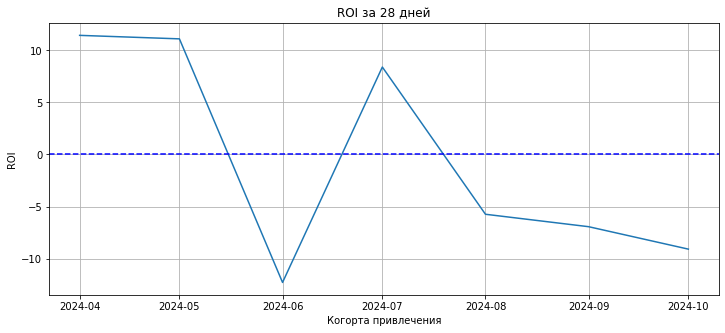

In [16]:
# Рассчитаем ROI с учётом покупок, совершённых за 28 дней с момента привлечения
roi_df = ltv_df.merge(cac_df, on='cohort')

roi_df['roi'] = ((roi_df['ltv_total'] - roi_df['avg_cac'] * roi_df['new_users_count'])
                 / (roi_df['avg_cac'] * roi_df['new_users_count'])) * 100

# Cтроим график в matplotlib
plt.subplots(figsize=(12,5))
plt.plot(roi_df['cohort'], roi_df['roi'])
plt.title('ROI за 28 дней')
plt.xlabel('Когорта привлечения')
plt.ylabel('ROI')
plt.axhline(y=0, color='blue', linestyle='--')

plt.grid()
plt.show()

- По показателю ROI мы видим, что до изменения контента и стратегии привлечения маркетинговые расходы окупались, а после этого (в среднем) - окупаться перестали, за исключением июля, когда произошел резкий рост LTV. Усиление маркетинга привело к росту CAC, который влияет на снижение ROI. 

* [Назад к содержанию](#10-bullet)
---
<a class="anchor" id="4-bullet"></a>
## 4 Анализ метрик в разрезе источника привлечения

Теперь проанализируем, какие источники привлечения перспективны, а какие за 28 дней не окупились.


<a class="anchor" id="41-bullet"></a>
### 4.1 Самые популярные источники привлечения

Определим самые популярные источники привлечения:
- Посчитаем общее число привлечённых пользователей для каждого источника.
- Визуализируем динамику набора новых пользователей по дням в каждом источнике.
- Рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

In [17]:
# Рассчитаем общее число уникальных пользователей по каналу привлечения first_channel
channels = (profiles_28.groupby('first_channel')['user_id'].nunique().reset_index()
            .rename(columns={'user_id':'new_users'})
            .sort_values(by='new_users', ascending=False))

display(channels)

,first_channel,new_users
0,FaceBoom,24339
3,TipTop,15413
2,RocketSuperAds,12492
1,MediaTornado,12311


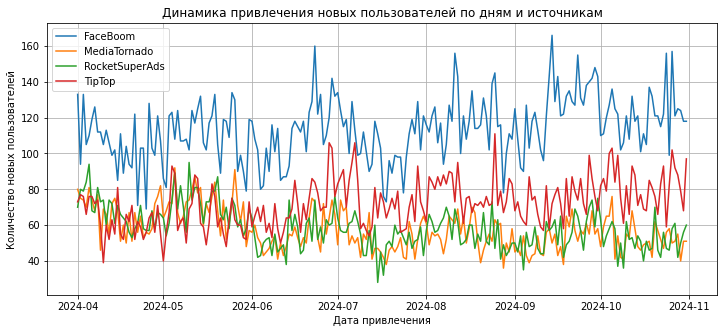

In [18]:
# Рассчитаем динамику набора новых пользователей по дням в каждом источнике
daily_new_users = (profiles_28.groupby(['first_dt', 'first_channel'])['user_id'].nunique().reset_index()
            .rename(columns={'user_id':'new_users'}))

# Cтроим график 
plt.subplots(figsize=(12,5))

sns.lineplot(data=daily_new_users, 
             x='first_dt', 
             y='new_users', 
             hue='first_channel')          

plt.title('Динамика привлечения новых пользователей по дням и источникам')
plt.xlabel('Дата привлечения')
plt.ylabel('Количество новых пользователей')
plt.legend()

plt.grid()
plt.show()

- `FaceBoom` является крупнейшим источником привлечения пользователей, значительно опережая остальные. Это указывает на то, что скорее всего новая маркетинговая стратегия, скорректированная к лету, делает основной упор на этот канал для обеспечения большого объема трафика.

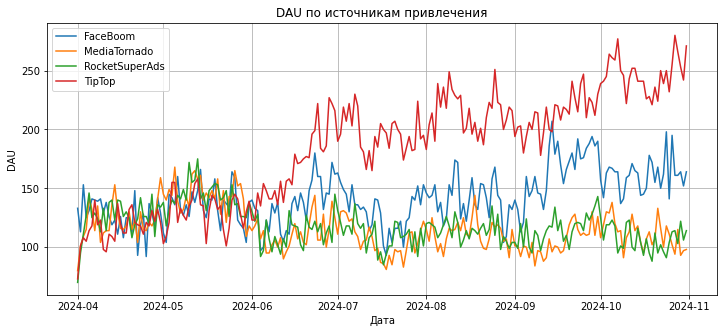

In [19]:
# Рассчитаем и визуализируем динамику DAU по источникам привлечения
dau_by_channel = (visits_28.groupby(['session_start', 'first_channel'])['user_id'].nunique().reset_index()
      .rename(columns={'session_start':'date', 'user_id':'dau'}))

dau_by_channel_plot = dau_by_channel[dau_by_channel['date'] < '2024-11-01']

# Cтроим график 
plt.figure(figsize=(12, 5))
sns.lineplot(data=dau_by_channel_plot, x='date', y='dau', hue='first_channel')
plt.title('DAU по источникам привлечения')
plt.xlabel('Дата')
plt.ylabel('DAU')
plt.legend()
                                  
plt.grid()
plt.show()

- `TipTop` является доминирующим источником по абсолютному числу ежедневных активных пользователей (DAU).

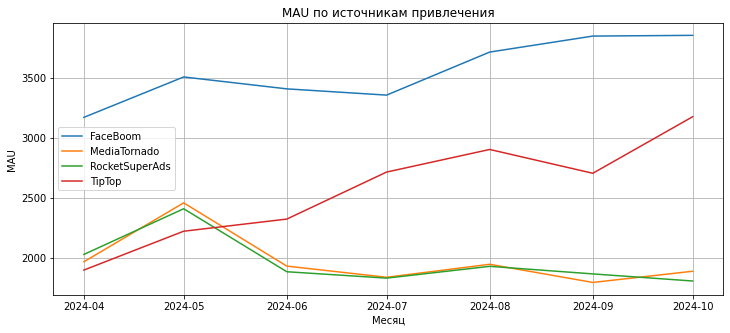

In [20]:
# Рассчитаем и визуализируем динамику MAU по источникам привлечения
mau_by_channel = (visits_28.groupby(['month', 'first_channel'])['user_id'].nunique().reset_index()
      .rename(columns={'user_id':'mau'}))

mau_by_channel_plot = mau_by_channel[mau_by_channel['month'] < '2024-11-01']

# Cтроим график
plt.figure(figsize=(12, 5))
sns.lineplot(data=mau_by_channel_plot, x='month', y='mau', hue='first_channel')
plt.title('MAU по источникам привлечения')
plt.xlabel('Месяц')
plt.ylabel('MAU')
plt.legend()
                                  
plt.grid()
plt.show()

- `FaceBoom` и `TipTop` показывают значительный рост месячной активной аудитории, относительно других источников привлечения. 

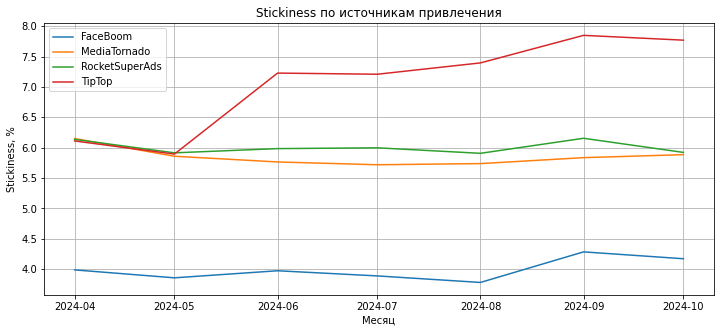

In [21]:
# Добавляем месяц к DAU
dau_by_channel['month'] = dau_by_channel['date'].dt.to_period('M').dt.to_timestamp()

avg_dau_by_channel = (dau_by_channel.groupby(['month', 'first_channel'])['dau'].mean().reset_index()
    .rename(columns={'dau':'avg_dau'}))

# Оставляем только полные месяцы
mau_clean = mau_by_channel[mau_by_channel['month'] < '2024-11-01']
avg_dau_clean = avg_dau_by_channel[avg_dau_by_channel['month'] < '2024-11-01']

# Рассчитаем и визуализируем динамику Stickiness по источникам привлечения
stick_by_channel = mau_clean.merge(avg_dau_clean, on=['month', 'first_channel'])

stick_by_channel['stick'] = 100 * (stick_by_channel['avg_dau'] / stick_by_channel['mau'])

# Cтроим график 
plt.figure(figsize=(12, 5))
sns.lineplot(data=stick_by_channel, x='month', y='stick', hue='first_channel')
plt.title('Stickiness по источникам привлечения')
plt.xlabel('Месяц')
plt.ylabel('Stickiness, %')
plt.legend()
                                  
plt.grid()
plt.show()

- Источник `TipTop` демонстрирует самые высокие значения DAU и Stickiness на протяжении всего анализируемого периода. Несмотря на то что объём привлечённых пользователей в этом канале ниже, чем у FaceBoom, аудитория TipTop заметно активнее и чаще возвращается в приложение. Это указывает на то, что данный канал приводит более заинтересованных и вовлечённых пользователей.

- Для источника `FaceBoom` наблюдается противоположная картина: при высоком значении MAU показатели DAU и Stickiness остаются низкими. Это свидетельствует о том, что канал обеспечивает большой приток пользователей, однако значительная часть аудитории не возвращается в приложение регулярно. Вероятно, FaceBoom приводит менее вовлечённый трафик, что может негативно влиять на показатели LTV и ROI и быть одной из причин стагнации выручки.

* [Назад к содержанию](#10-bullet)
---
<a class="anchor" id="42-bullet"></a>
### 4.2 Динамика изменения метрик на 28-й день в разрезе источника

Изучим динамику изменения метрик на 28-й день в разрезе источника. Проведем анализ с выделением недельных когорт по дате привлечения. Рассчитаем и визуализируем:
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.
- Недельную динамику затрат на маркетинг по каждому источнику привлечения.
- Динамику среднего CAC, значений LTV и ROI.

По результатам проведем анализ рекламных каналов. Дадим общую характеристику каждому рекламному каналу по рассчитанным метрикам. Укажем, какие рекламные каналы не вышли на уровень окупаемости за ожидаемый период, и предположим почему.

In [22]:
# Определяем недельную когорту
profiles['cohort_week'] = profiles['first_dt'].dt.to_period('W').apply(lambda x: x.start_time)
cohort_week_size = (profiles.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index()
                   .rename(columns={'user_id':'cohort_users'}))

visits['cohort_week'] = visits['first_dt'].dt.to_period('W').apply(lambda x: x.start_time)
orders['cohort_week'] = orders['first_dt'].dt.to_period('W').apply(lambda x: x.start_time)
costs['cohort_week'] = costs['dt'].dt.to_period('W').apply(lambda x: x.start_time)

# Определяем недельные когорты по лайфтайму
orders['week_lifetime'] = orders['lifetime'] // 7 + 1
visits['week_lifetime'] = visits['lifetime'] // 7 + 1

- При анализе метрик на 28-й день будем учитывать только те недельные когорты, для которых на момент расчёта прошло не менее 28 дней с момента привлечения. Это позволяет избежать искажений, связанных с неполным периодом наблюдения.

In [23]:
# Оставляем только когорты, которым исполнилось минимум 28 дней
valid_date = visits['session_start'].max() - pd.Timedelta(days=28)

# Оставляем только зрелые когорты
cohort_week_size_valid = cohort_week_size[
    cohort_week_size['cohort_week'] <= valid_date]

- Рассчитаем процент пользователей из исходной когорты, которые были активны хотя бы один раз в период с 14-го по 28-й день жизни (скользящее удержание на 14-й день с момента привлечения).

,cohort_week,first_channel,cohort_users,active_users,retention
0,2024-04-01,FaceBoom,820,10,1.219512
1,2024-04-01,MediaTornado,522,48,9.195402
2,2024-04-01,RocketSuperAds,542,67,12.361624
3,2024-04-01,TipTop,516,66,12.790698
4,2024-04-08,FaceBoom,749,10,1.335113


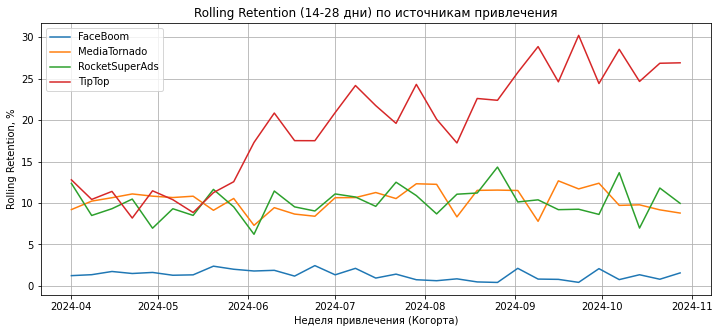

In [24]:
# Фильтруем посещения за период с 14-го по 28-й день
visits_14_28 = visits[(visits['lifetime'] >= 14) & 
                      (visits['lifetime'] <= 27) &
                      (visits['cohort_week'].isin(cohort_week_size_valid['cohort_week']))]

# Считаем уникальных активных пользователей
active_14_28 = (visits_14_28.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index()
                   .rename(columns={'user_id':'active_users'}))

# Рассчитаем rolling_retention 
rr_df = cohort_week_size_valid.merge(active_14_28, how='left', on=['cohort_week', 'first_channel'])
rr_df['active_users'] = rr_df['active_users'].fillna(0)
rr_df['retention'] = 100 * (rr_df['active_users'] / rr_df['cohort_users'])

display(rr_df.head())
print()

# Cтроим график 
plt.figure(figsize=(12, 5))
sns.lineplot(data=rr_df, x='cohort_week', y='retention', hue='first_channel')
plt.title('Rolling Retention (14-28 дни) по источникам привлечения')
plt.xlabel('Неделя привлечения (Когорта)')
plt.ylabel('Rolling Retention, %')
plt.legend()
                                  
plt.grid()
plt.show()

- `TipTop` демонстрирует значительно более высокий Rolling Retention - это говорит о том, что пользователи, пришедшие из этого канала, являются наиболее лояльными и возвращаются в приложение спустя 14 дней.
- `MediaTornado` и `RocketSuperAds` показывают стабильно средние показатели RR (8-15%).
- `FaceBoom` имеет аномально низкий RR (стабильно ниже 2%). Это подтверждает, что этот канал привлекает пользователей, которые практически не возвращаются в приложение после первых двух недель, что ставит под сомнение качество этого трафика.


Рассчитаем конверсию в покупку на 4-й неделе.

,cohort_week,first_channel,cohort_users,payers,conversion
0,2024-04-01,FaceBoom,820,93,11.341463
1,2024-04-01,MediaTornado,522,24,4.597701
2,2024-04-01,RocketSuperAds,542,45,8.302583
3,2024-04-01,TipTop,516,48,9.302326
4,2024-04-08,FaceBoom,749,78,10.413885


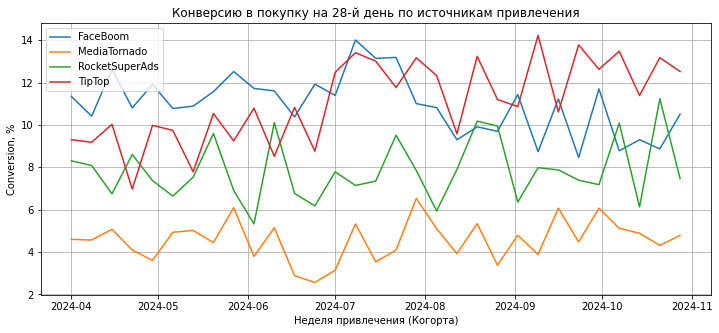

In [25]:
# Количество пользователей, совершивших хотя бы одну покупку за первые 28 дней
orders_28 = orders[orders['lifetime'] <= 27]

orders_weekly = (orders_28.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index()
         .rename(columns={'user_id':'payers'}))

# Рассчитаем conversion_rate 
cr_df = cohort_week_size_valid.merge(orders_weekly, how='left', on=['cohort_week', 'first_channel'])
cr_df['payers'] = cr_df['payers'].fillna(0)
cr_df['conversion'] = 100 * (cr_df['payers'] / cr_df['cohort_users'])

display(cr_df.head())
print()

# Cтроим график 
plt.figure(figsize=(12, 5))
sns.lineplot(data=cr_df, x='cohort_week', y='conversion', hue='first_channel')
plt.title('Конверсию в покупку на 28-й день по источникам привлечения')
plt.xlabel('Неделя привлечения (Когорта)')
plt.ylabel('Conversion, %')
plt.legend()
                                  
plt.grid()
plt.show()

- Показатели конверсии в покупку (CR) наиболее высоки у `TipTop` и `FaceBoom`. Это означает, что несмотря на низкую вовлеченность, пользователи `FaceBoom` склонны совершать быстрые, единичные покупки, но не остаются активными.
- `MediaTornado` имеет самую низкую CR (3-6%).


Рассчитаем недельную динамику затрат на маркетинг по каждому источнику привлечения.

,cohort_week,first_channel,costs
0,2024-04-01,FaceBoom,769.875901
1,2024-04-01,MediaTornado,129.318322
2,2024-04-01,RocketSuperAds,466.650000
3,2024-04-01,TipTop,393.989381
4,2024-04-08,FaceBoom,698.872741


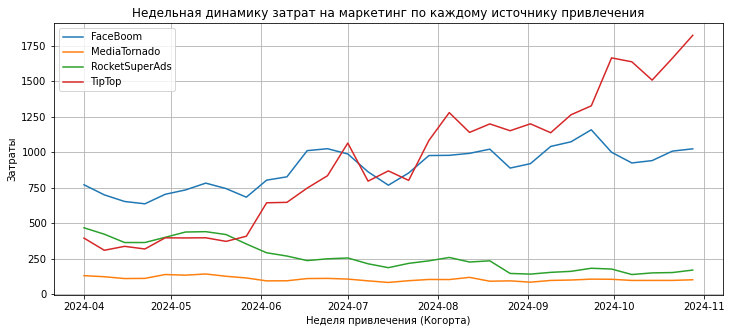

In [26]:
# Рассчитываем недельную динамику затрат на маркетинг по каждому источнику привлечения
costs_weekly = (costs.groupby(['cohort_week', 'channel'])['costs'].sum().reset_index()
                .rename(columns={'channel':'first_channel'}))

# Oставляем только зрелые когорты
costs_weekly = costs_weekly[costs_weekly['cohort_week'] <= valid_date]

display(costs_weekly.head())
print()

# Cтроим график 
plt.figure(figsize=(12, 5))
sns.lineplot(data=costs_weekly, x='cohort_week', y='costs', hue='first_channel')
plt.title('Недельная динамику затрат на маркетинг по каждому источнику привлечения')
plt.xlabel('Неделя привлечения (Когорта)')
plt.ylabel('Затраты')
plt.legend()
                                  
plt.grid()
plt.show()

- `TipTop` и `FaceBoom` являются самыми крупными источниками затрат, причем расходы на `TipTop` демонстрируют агрессивный рост со второго полугодия.
- `RocketSuperAds` показывает небольшое снижение затрат после лета.
- `MediaTornado` - стабильно самый дешевый канал.


Рассчитаем динамику среднего CAC, значений LTV и ROI.

,cohort_week,first_channel,avg_cac
0,2024-04-01,FaceBoom,0.938873
1,2024-04-01,MediaTornado,0.247736
2,2024-04-01,RocketSuperAds,0.860978
3,2024-04-01,TipTop,0.763545
4,2024-04-08,FaceBoom,0.933074


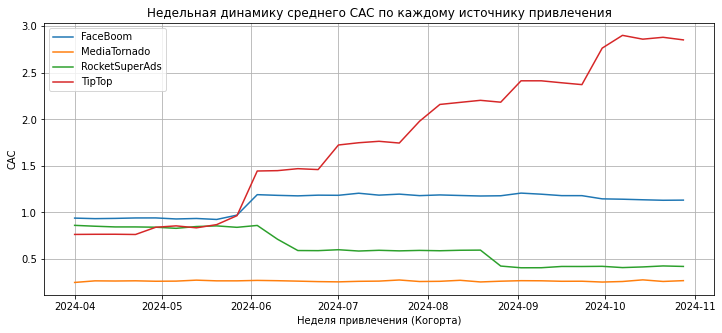

In [27]:
# Рассчитаем динамику среднего CAC
cac_weekly = (profiles.groupby(['cohort_week', 'first_channel'])['cac'].mean().reset_index()
              .rename(columns={'cac':'avg_cac'}))

# Oставляем только зрелые когорты
cac_weekly = cac_weekly[cac_weekly['cohort_week'] <= valid_date]

display(cac_weekly.head())
print()

# Cтроим график 
plt.figure(figsize=(12, 5))
sns.lineplot(data=cac_weekly, x='cohort_week', y='avg_cac', hue='first_channel')
plt.title('Недельная динамику среднего CAC по каждому источнику привлечения')
plt.xlabel('Неделя привлечения (Когорта)')
plt.ylabel('CAC')
plt.legend()
                                  
plt.grid()
plt.show()

- `TipTop` является самым дорогим каналом по привлечению - его CAC резко вырос с июня. Это говорит о сильной конкуренции или насыщении аудитории в этом канале. Агрессивные инвестиции в `TipTop` могут привеcти к сильному удорожанию привлечения, что является серьезным риском для окупаемости.
- CAC у `FaceBoom` стабилен и находится на среднем уровне.
- CAC у `RocketSuperAds` с июня уменьшился.
- `MediaTornado` - самый дешевый канал, CAC стабильно держится ниже 0.5. 

,cohort_week,first_channel,ltv_total,cohort_users,ltv
0,2024-04-01,FaceBoom,380.36,820,0.463854
1,2024-04-01,MediaTornado,191.43,522,0.366724
2,2024-04-01,RocketSuperAds,724.33,542,1.336402
3,2024-04-01,TipTop,795.40,516,1.541473
4,2024-04-08,FaceBoom,337.06,749,0.450013


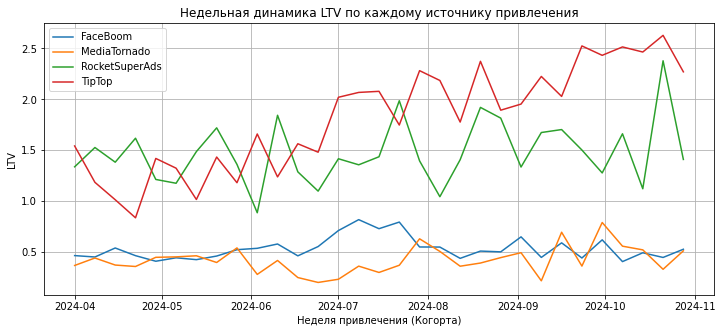

In [28]:
# Суммируем LTV для каждой недели
ltv_weekly = (orders_28.groupby(['cohort_week', 'first_channel'])['revenue'].sum().reset_index()
              .rename(columns={'revenue':'ltv_total'}))

# Добавляем размер когорты
ltv_weekly = ltv_weekly.merge(cohort_week_size, on=['cohort_week', 'first_channel'])
ltv_weekly['ltv'] = ltv_weekly['ltv_total'] / ltv_weekly['cohort_users'] 

# Oставляем только зрелые когорты
ltv_weekly = ltv_weekly[ltv_weekly['cohort_week'] <= valid_date]

display(ltv_weekly.head())
print()

# Cтроим график 
plt.figure(figsize=(12, 5))

sns.lineplot(data=ltv_weekly, x='cohort_week', y='ltv', hue='first_channel')
plt.title('Недельная динамика LTV по каждому источнику привлечения')
plt.xlabel('Неделя привлечения (Когорта)')
plt.ylabel('LTV')
plt.legend()

plt.grid()
plt.show()

- `TipTop`с середины июня демонстрирует самый высокий LTV за счет его высокой лояльности RR.
- `RocketSuperAds` находится на втором месте по LTV.
- `FaceBoom` и `MediaTornado` - минимальный LTV.

,cohort_week,first_channel,ltv_total,cohort_users,ltv,avg_cac,roi
0,2024-04-01,FaceBoom,380.36,820,0.463854,0.938873,-50.594635
1,2024-04-01,MediaTornado,191.43,522,0.366724,0.247736,48.030068
2,2024-04-01,RocketSuperAds,724.33,542,1.336402,0.860978,55.219115
3,2024-04-01,TipTop,795.40,516,1.541473,0.763545,101.883614
4,2024-04-08,FaceBoom,337.06,749,0.450013,0.933074,-51.770905


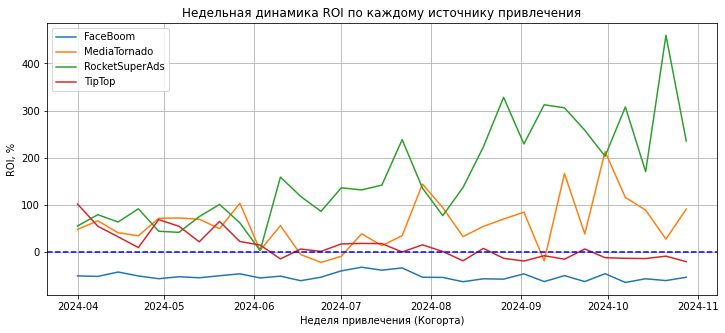

In [29]:
# Объединяем CAC и LTV 
roi_weekly = ltv_weekly.merge(cac_weekly, on=['cohort_week', 'first_channel'])

# Расчёт ROI
roi_weekly['roi'] = (roi_weekly['ltv'] - roi_weekly['avg_cac']) / roi_weekly['avg_cac'] * 100

display(roi_weekly.head())
print()

# Cтроим график
plt.figure(figsize=(12, 5))

sns.lineplot(data=roi_weekly, x='cohort_week', y='roi', hue='first_channel')
plt.title('Недельная динамика ROI по каждому источнику привлечения')
plt.xlabel('Неделя привлечения (Когорта)')
plt.ylabel('ROI, %')
plt.axhline(y=0, color='blue', linestyle='--')
plt.legend()

plt.grid()
plt.show()

- `RocketSuperAds` является единственным каналом, который стабильно демонстрирует положительный ROI и после июня ROI канала имеет восходящий тренд. Это означает, что пользователи, привлечённые через этот канал, окупают привлечённые рекламные инвестиции. Канал можно считать высокоэффективным и с хорошей монетизацией аудитории. 

- `MediaTornado` тоже достаточно стабилен в плане окупаемости.

- `TipTop` ROI нестабилен, наблюдаются «пики» положительной окупаемости, но они кратковременны. До внедрения изменений канал окупался, после июня - канал можно считать убыточным.

- `FaceBoom` - стабильно убыточный канал: ROI почти всегда (до внедрения изменений и после) находится в диапазоне около –50%. Положительных периодов по ROI нет. Привлечённая аудитория практически не монетизируется, что и приводит к хроническому отрицательному ROI.


 
 
 

- Общая характеристика рекламных каналов: 
    - `RocketSuperAds`: самый эффективный с точки зрения окупаемости. ROI по каналу стабильно положительный, а начиная с июня демонстрирует выраженный восходящий тренд. Несмотря на заметные колебания LTV, его уровень остаётся достаточно высоким, чтобы уверенно перекрывать CAC, который после июня снизился, что улучшило маржинальность канала. RR средний. Канал привлекает платежеспособную аудиторию, которая регулярно совершают покупки и обеспечивают устойчивую окупаемость маркетинговых инвестиций.
    
    - `MediaTornado`: стабильный, дешевый, но второй по окупаемости канал. `MediaTornado` занимает среднюю позицию практически по всем метрикам: ROI достаточно стабилен и положителен. LTV и RR - седние. CAC и CR - самые низкие. Расходы на канал - самые низкие и практически не меняются. `MediaTornado` приводит дешёвую, массовую и умеренно вовлечённую аудиторию, которая не склонна активно покупать, но при этом ведёт себя стабильно и предсказуемо, что позволяет каналу показывать положительный ROI благодаря низкому CAC.

    - `TipTop`: канал с качественной и лояльной аудиторией, но не окупается. До внедрения изменений `TipTop` демонстрировал уровень окупаемости, сопоставимый с другими каналами, однако после июня ROI стал нестабильным и чаще находится около нуля или в отрицательной зоне. Канал показывает лучшие продуктовые метрики: самые высокие значения RR, LTV и CR, что свидетельствует о высокой вовлечённости и лояльности пользователей. Основной фактор ухудшения окупаемости - резкий рост CAC, что резко ухудшило окупаемость. Несмотря на отличное качество аудитории, слишком высокая стоимость её привлечения приводит к просадке ROI. Канал стал слишком дорогим.
    
    - `FaceBoom`: самый слабый и убыточный канал на протяжении всего анализируемого периода — как до, так и после внедрения изменений. Несмотря на быстрые конверсии в покупки, канал остаётся провальным с точки зрения долгосрочной ценности и окупаемости: ROI стабильно отрицательный. RR аномально низкий - пользователи не возвращаются после первых двух недель. LTV один из самых низких. CR высокая - пользователи делают быстрые единичные покупки, но исчезают. Расходы на канал высокие (вторые после `TipTop`). Канал привлекает импульсивных пользователей, которые совершают единичные покупки, но совершенно не удерживаются. 

* [Назад к содержанию](#10-bullet)
---
<a class="anchor" id="5-bullet"></a>
## 5 Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости (`TipTop` и `FaceBoom`), рассчитаем и визуализируем в виде тепловой карты значения ROI за больший период, например за 8–10 недель.

Разделим данные на недельные когорты по дате привлечения, в качестве интервала наблюдений используем недели.

Сделаем вывод о том, за какой период окупаются вложения в эти источники.

In [30]:
# Фильтруем базу пользователей 
channels = ['TipTop', 'FaceBoom']

#profiles_filtered = profiles[profiles['first_channel'].isin(channels)]
orders_filtered = orders[orders['first_channel'].isin(channels)].copy()
costs_filtered = costs[costs['channel'].isin(channels)].copy()

# Считаем недели жизни для заказов
orders_filtered = orders_filtered[orders_filtered['week_lifetime'] < 10]

# Считаем накопленный LTV каждой когорты
ltv_weekly = orders_filtered.groupby(['first_channel', 'cohort_week', 'week_lifetime'])['revenue'].sum().reset_index()
ltv_weekly = ltv_weekly.sort_values(['first_channel', 'cohort_week', 'week_lifetime'])

ltv_weekly['ltv_cum'] = (ltv_weekly
    .groupby(['first_channel', 'cohort_week'])['revenue'].cumsum())

# Считаем фиксированный CAC на уровне когорты
cac_weekly = (costs_filtered.groupby(['channel', 'cohort_week'])['costs'].sum().reset_index()
              .rename(columns={'channel': 'first_channel'}))

# Объединяем таблицы с LTV, CAC для расчета ROI
roi_df = ltv_weekly.merge(cac_weekly, on=['first_channel', 'cohort_week'], how='left')

#Считаем ROI
roi_df['roi'] = (roi_df['ltv_cum'] - roi_df['costs']) / roi_df['costs']


display(roi_df.head())

,first_channel,cohort_week,week_lifetime,revenue,ltv_cum,costs,roi
0,FaceBoom,2024-04-01,1,325.03,325.03,769.875901,-0.577815
1,FaceBoom,2024-04-01,2,49.35,374.38,769.875901,-0.513714
2,FaceBoom,2024-04-01,4,5.98,380.36,769.875901,-0.505946
3,FaceBoom,2024-04-01,6,2.99,383.35,769.875901,-0.502063
4,FaceBoom,2024-04-08,1,307.15,307.15,698.872741,-0.560507


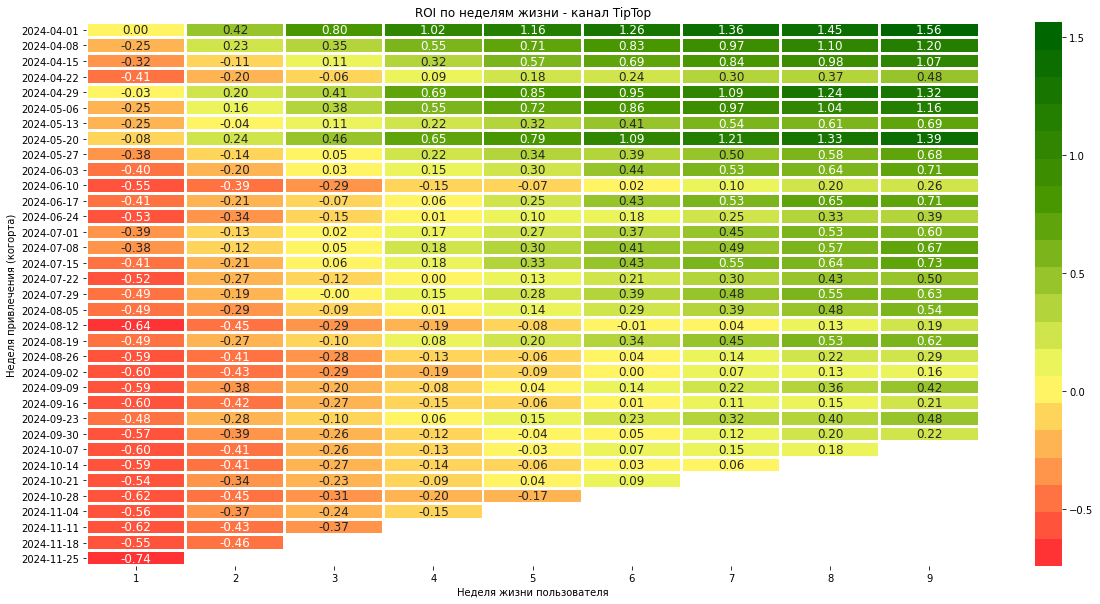

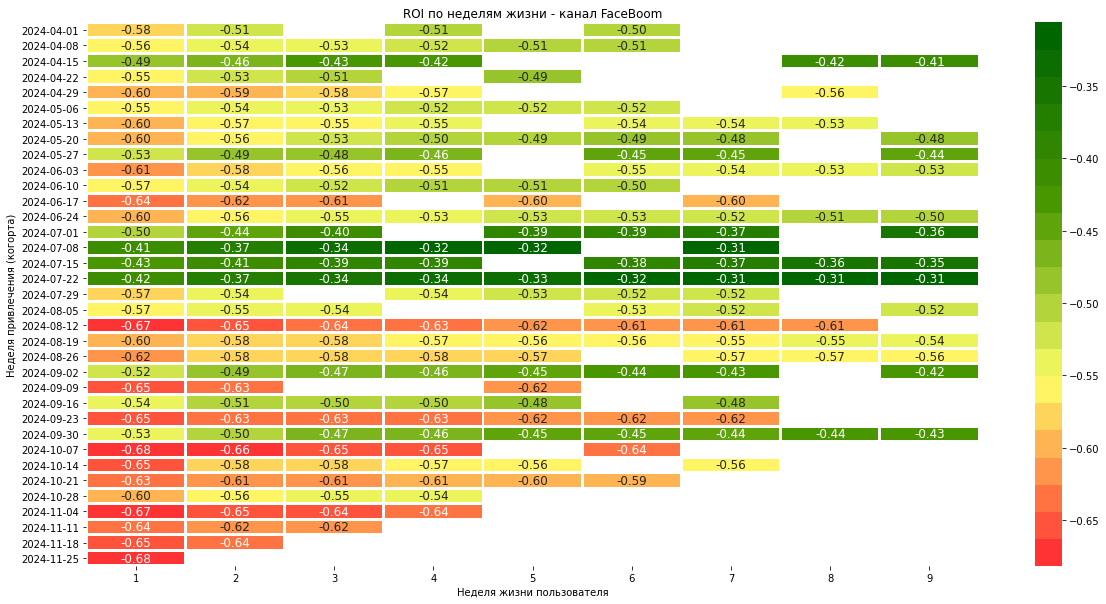

In [31]:
# Создадим функцию построения тепловой карты ROI по каналам
def roi_heatmap(df, channel):
    df_channel = df[(df['first_channel']==channel) &
            (df['week_lifetime'] < 10)].copy()
    
    # Пивотируем данные, чтобы cohort_week был индексом, а week_lifetime - столбцом
    df_pivot = df_channel.pivot(index='cohort_week', columns='week_lifetime', values='roi')
    
    # Меняем формат индекса внутри графика
    df_pivot.index = df_pivot.index.date
    
    # Заменим нули на NaN для корректной отрисовки
    df_pivot[df_pivot == 0] = float('nan')

    cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900', '#006600'], N=20)

    # Построим heatmap
    plt.figure(figsize=(20, 10))

    sns.heatmap(df_pivot,
          cmap=cmap,
          annot=True,
          fmt='.2f',
          linewidths=2,
          annot_kws={"size": 12})


    plt.title(f'ROI по неделям жизни - канал {channel}')
    plt.xlabel('Неделя жизни пользователя')
    plt.ylabel('Неделя привлечения (когорта)')
    plt.show()
    
roi_heatmap(roi_df, 'TipTop')
roi_heatmap(roi_df, 'FaceBoom')

- `TipTop`
    - До июня (апрель–май) большинство когорт канала выходят на положительный ROI уже на 2-3 неделе жизни, а к 4-5 неделе демонстрируют устойчивый рост окупаемости. Это говорит о том, что до изменения маркетинговой стратегии канал эффективно привлекал аудиторию, способную достаточно быстро компенсировать затраты на привлечение.
    - Начиная с июня наблюдается чёткое смещение срока окупаемости вправо. Для летних когорт положительный ROI достигается позже, как правило, не раньше 4–6 недели, а для осенних когорт (сентябрь–октябрь) либо появляется только ближе к 5-6 неделе.
    - Таким образом, несмотря на рост интереса к продукту после появления спортивного контента, привлечение через `TipTop` перестало стабильно окупаться в целевые 28 дней. Это указывает на то, что новая аудитория привлекается по более высокой цене, что снижает краткосрочную финансовую эффективность канала.


- `FaceBoom`    
    - Все когорты канала `FaceBoom`, как привлечённые до, так и после изменений в продукте, демонстрируют устойчиво отрицательный ROI на всём горизонте до 10 недель жизни. Ни одна из когорт не выходит на точку окупаемости даже в долгосрочном периоде.
    - При этом на графике отсутствует выраженная положительная динамика ROI по мере роста лайфтайма: значения остаются в отрицательной зоне и колеблются вокруг схожих уровней. Это указывает на то, что дополнительные недели жизни пользователя не приводят к значимому росту LTV, достаточному для компенсации затрат на привлечение.
    - Следовательно, канал `FaceBoom` структурно неокупаем:привлекает аудиторию с низкой платёжной способностью и слабой склонностью к повторным покупкам. Запуск нового контента не оказал заметного влияния на экономику канала, и `FaceBoom` остаётся убыточным источником привлечения даже при увеличении горизонта анализа.

* [Назад к содержанию](#10-bullet)
---
<a class="anchor" id="6-bullet"></a>
## 6 Выводы и рекомендации

Сформулируйте общий вывод. Зафиксируйте основные результаты и инсайты. Например, охарактеризуйте аудиторию продукта, покажите распределение маркетинговых затрат по каналам привлечения, опишите каждый канал привлечения. Делайте акцент на сильных и слабых сторонах. Укажите, какие каналы привлечения не вышли на окупаемость и по каким причинам.

Дайте рекомендации отделу маркетинга: опишите, как повысить эффективность вложений в рекламу.


Приложение Procrastinate Pro+ после внедрения нового спортивного контента и корректировки маркетинговой стратегии летом 2024 года демонстрирует: 
- Рост аудитории: DAU увеличился с ~350 до ~900 пользователей в день, MAU — с ~9 000 до ~14 000 пользователей в месяц.
- Вовлеченность: Stickiness вырос с 5,3% до 6,2%, что указывает на то, что новые пользователи не стали существенно более вовлечёнными, чем старые.
- Финансовые метрики:
    - CAC растёт с мая-июня, особенно в каналах `TipTop` и `FaceBoom`.
    - LTV растёт только в середине года, после чего снижается к ноябрю.
    - ROI большинства когорт отрицателен с июня, что указывает на стагнацию выручки и недостаточную окупаемость маркетинговых вложений за целевой период в 28 дней.

Таким образом, рост аудитории не конвертируется в пропорциональный рост дохода, главным образом из-за слабой вовлеченности и высокой стоимости привлечения новых пользователей.

- Основная аудитория — пользователи, интересующиеся развлекательным контентом. Новый спортивный контент привлек дополнительную аудиторию, ориентированную на спорт и здоровый образ жизни.
    - Пользователи из `TipTop` - самые лояльные (высокий Rolling Retention и LTV), но дорогие в привлечении.
    - Пользователи из `FaceBoom` - импульсивные, совершают быстрые покупки, но практически не возвращаются, что приводит к низкому LTV и отрицательному ROI.


- Маркетинговые каналы:
    - `FaceBoom`
        - Сильные стороны: высокая конверсия в быструю покупку.
        - Слабые стороны: низкая вовлеченность (RR < 2%), низкий LTV, стабильный отрицательный ROI (~–50%).
        - Окупаемость не достигается даже за 10 недель.
        - Вывод: канал убыточен, привлекает аудиторию с низкой долгосрочной ценностью.

    - `MediaTornado`
        - Сильные стороны: низкий CAC, стабильный положительный ROI (~48%), предсказуемая аудитория.
        - Слабые стороны: низкая конверсия в покупки (3–6%), средний LTV.
        - Окупаемость достигается в пределах 4 недель.
        - Вывод: стабильный и дешёвый канал с умеренной эффективностью.

    - `RocketSuperAds`
        - Сильные стороны: стабильный положительный ROI (~55%), средний LTV, регулярные покупки.
        - Слабые стороны: рост CAC с июня незначителен, но канал чувствителен к объёму привлечения.
        - Окупаемость достигается в пределах 4 недель.
        - Вывод: самый эффективный канал с точки зрения окупаемости.

    - `TipTop`
        - Сильные стороны: самая лояльная аудитория (высокий RR), высокий LTV и конверсия в покупки.
        - Слабые стороны: резкий рост CAC с июня, нестабильный ROI, канал не окупается за 28 дней.
        - Окупаемость по когортам с июня смещается к 8–9 неделе, что превышает целевой период 28 дней.
        - Вывод: качественная аудитория, но высокая стоимость привлечения делает канал убыточным в краткосрочной перспективе.
        

Основные инсайты:
- Рост аудитории не всегда приводит к росту дохода: новые пользователи не демонстрируют высокой вовлеченности, поэтому LTV остаётся ограниченным.
- Каналы с высокой CAC (`TipTop`) создают риск отрицательного ROI, несмотря на лояльность аудитории.
- Каналы с низкой вовлеченностью (`FaceBoom`) привлекают краткосрочные покупки, но не обеспечивают долгосрочную монетизацию. Канал привлекает больше трети пользователей.
- Эффективные каналы (`RocketSuperAds`, `MediaTornado`) обеспечивают стабильный, пусть и умеренный, доход при низкой стоимости привлечения.

Рекомендации отделу маркетинга:
- Уменьшить расходы на `FaceBoom`, пока не решим проблему удержания.
- Сократить бюджет на `TipTop` в краткосрочной перспективе.
- Увеличить инвестиции в `RocketSuperAds` и `MediaTornado`, где ROI стабильно положителен.
- Отслеживать рост стоимости привлечения в `TipTop` и других популярных каналах, чтобы не допустить превышения LTV.